In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")


In [5]:
df = pd.read_csv("../data/processed/merged_clean.csv", parse_dates=["datetime"])

df.head()


,client_id,value,datetime
0,MAC000002,0.263,2012-10-13 00:00:00
1,MAC000002,0.269,2012-10-13 00:30:00
2,MAC000002,0.275,2012-10-13 01:00:00
3,MAC000002,0.256,2012-10-13 01:30:00
4,MAC000002,0.211,2012-10-13 02:00:00


In [6]:
print("Nombre de lignes :", len(df))
print("\nColonnes :")
print(df.dtypes)
print("\nValeurs manquantes :")
print(df.isna().sum())


Nombre de lignes : 5560366

Colonnes :
client_id            object
value               float64
datetime     datetime64[ns]
dtype: object

Valeurs manquantes :
client_id    0
value        0
datetime     0
dtype: int64


In [7]:
df.describe()


,value,datetime
count,5.560366e+06,5560366
mean,3.638608e-01,2013-04-15 17:05:05.487803136
min,0.000000e+00,2011-12-04 00:00:00
25%,1.050000e-01,2012-11-21 08:30:00
50%,2.030000e-01,2013-04-20 14:30:00
75%,4.280000e-01,2013-09-21 01:00:00
max,9.141000e+00,2014-02-27 23:30:00
std,4.519274e-01,NaN


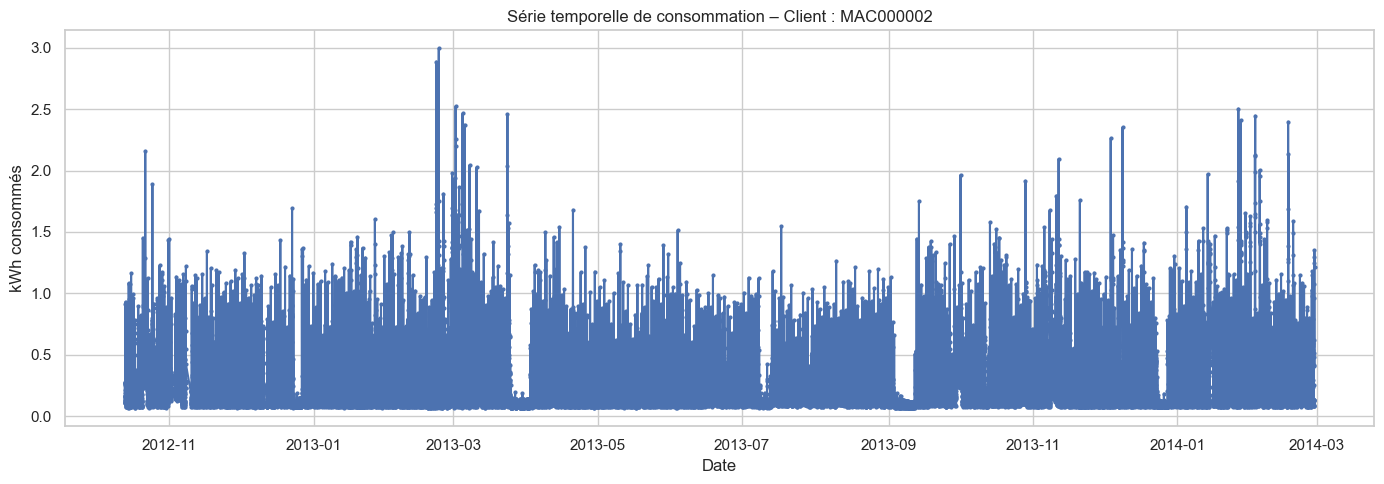

In [8]:
# Choisir un client
client_id = df["client_id"].unique()[0]
df_client = df[df["client_id"] == client_id].copy()

plt.figure(figsize=(14, 5))
plt.plot(df_client["datetime"], df_client["value"], marker='o', linestyle='-', markersize=2)
plt.title(f"Série temporelle de consommation – Client : {client_id}")
plt.xlabel("Date")
plt.ylabel("kWh consommés")
plt.grid(True)
plt.tight_layout()
plt.show()


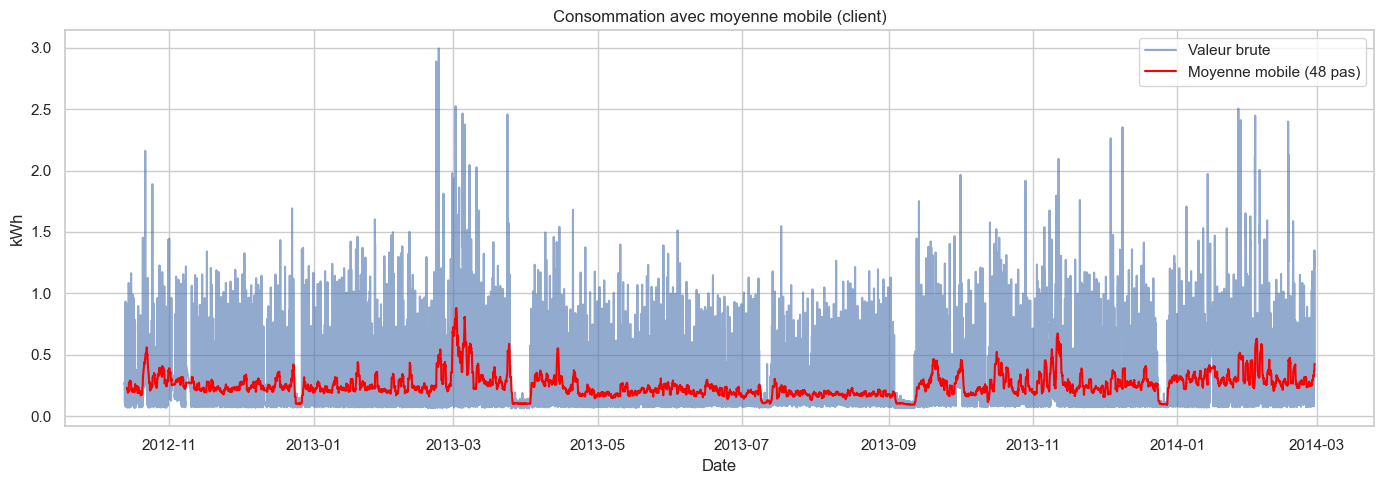

In [9]:
df_client["rolling_mean"] = df_client["value"].rolling(window=48).mean()

plt.figure(figsize=(14, 5))
plt.plot(df_client["datetime"], df_client["value"], label="Valeur brute", alpha=0.6)
plt.plot(df_client["datetime"], df_client["rolling_mean"], label="Moyenne mobile (48 pas)", color="red")
plt.title("Consommation avec moyenne mobile (client)")
plt.xlabel("Date")
plt.ylabel("kWh")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


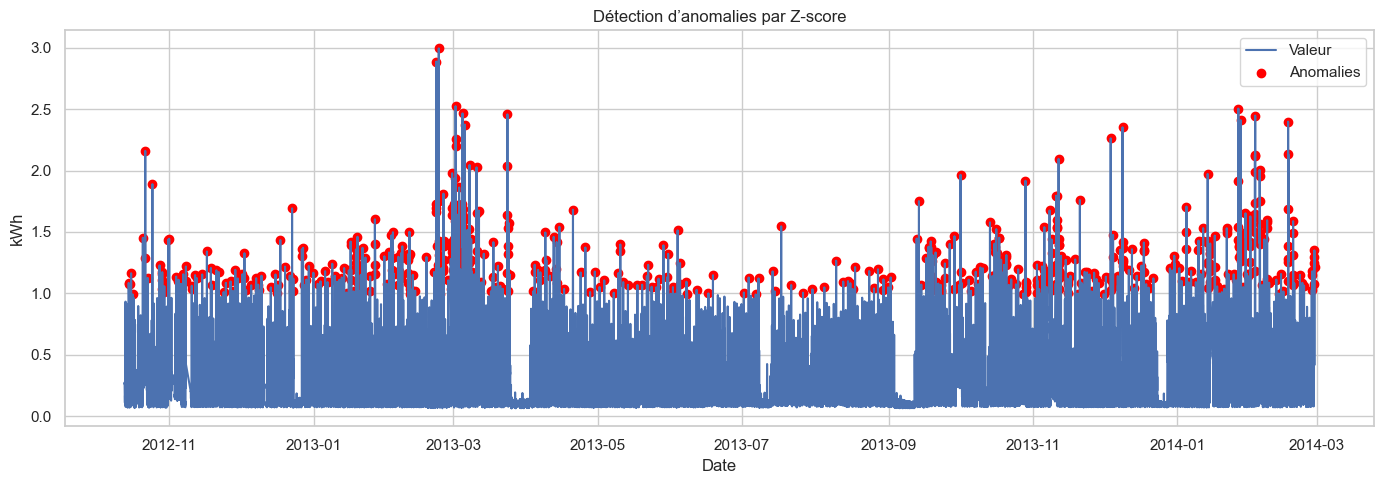

In [10]:
from scipy.stats import zscore

df_client["zscore"] = zscore(df_client["value"].fillna(0))
df_client["anomaly"] = df_client["zscore"].abs() > 3

plt.figure(figsize=(14, 5))
plt.plot(df_client["datetime"], df_client["value"], label="Valeur")
plt.scatter(df_client[df_client["anomaly"]]["datetime"],
            df_client[df_client["anomaly"]]["value"], color="red", label="Anomalies")
plt.title("Détection d’anomalies par Z-score")
plt.xlabel("Date")
plt.ylabel("kWh")
plt.legend()
plt.tight_layout()
plt.show()
